In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import sys

ROOT = Path.cwd().parent.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from scripts.src.helpers import parse_edges
import scripts.src.inputs.config as cfg
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
vehroutes_am  = Path("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/VehTraces_marouter_scaled1.0.xml")

tree = ET.parse(vehroutes_am)
root = tree.getroot()

data_list = []

for veh in root.findall("vehicle"):
    veh_data = {
        "id": veh.get("id"), 
        "depart": float(veh.get("depart")) if veh.get("depart") else None,
        "departLane": veh.get("departLane"),
        "departSpeed": float(veh.get("departSpeed")) if veh.get("departSpeed") else None,
        "fromTaz": veh.get("fromTaz"),
        "toTaz": veh.get("toTaz"),
        "speedFactor": float(veh.get("speedFactor")) if veh.get("speedFactor") else None, # Corretto refuso 'fpeedFactor'
        "arrival": float(veh.get("arrival")) if veh.get("arrival") else None,
        "routeLength": float(veh.get("routeLength")) if veh.get("routeLength") else None,
    }
    
    route = veh.find("route")
    if route is not None:
        veh_data["route_edges"] = route.get("edges")
        veh_data["route_exitTimes"] = route.get("exitTimes") if route.get("exitTimes") else None
    
    param = veh.find("param")
    if param is not None:
        veh_data["param_key"] = param.get("key")
        veh_data["param_value"] = float(param.get("value"))
        
    data_list.append(veh_data)

df_res = pd.DataFrame(data_list)
df_res

,id,depart,departLane,departSpeed,fromTaz,toTaz,speedFactor,arrival,routeLength,route_edges,route_exitTimes
0,577,21.0,best,21.6689,10007,10012,0.9752,109.0,1194.17,1306068768#2 134572328#0 134572328#1 130547465...,22.00 22.00 25.00 26.00 26.00 26.00 26.00 26.0...
1,913,23.0,best,15.0380,10012,10007,1.0827,76.0,742.44,678628384#5 678628384#6 -38081508#4 -38081508#...,30.00 35.00 41.00 46.00 52.00 60.00 68.00 68.0...
2,1995,28.0,best,16.6736,635,10002,1.2004,96.0,1148.74,-154986390 -4761525#1 116647088#0 116647088#1 ...,36.00 39.00 42.00 45.00 52.00 52.00 52.00 52.0...
3,1243,30.0,best,14.5262,10017,10001,1.0458,102.0,1108.00,-39971293 121952572#3 121952572#4 121952572#5 ...,36.00 36.00 36.00 40.00 40.00 41.00 41.00 41.0...
4,1537,31.0,best,11.7647,573,10009,1.0777,32.0,4.60,1167094068#0 -1307179610#0 -659342821 -1307179...,32.00 32.00 32.00 32.00 32.00 32.00
...,...,...,...,...,...,...,...,...,...,...,...
327102,329881,86389.0,best,16.8564,10017,10001,1.2136,NaN,103.27,39971293 274564579#0 274564579#1 274564576#0 2...,86394.00 86396.00 -1 -1 -1 -1 -1 -1 -1 -1 -1 -...
327103,330843,86390.0,best,25.0000,573,10009,1.1279,86391.0,0.60,-1307179610#0 -659342821 -1307179611#3,86391.00 86391.00 86391.00
327104,332293,86391.0,best,13.9900,635,10002,1.0072,86392.0,1.07,116647088#5 36357295 397427448#0,86392.00 86392.00 86392.00
327105,328923,86393.0,best,15.0290,10012,10007,1.0820,NaN,0.00,38081498 38081500#1 134460789#2 134460789#3 13...,-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1


In [3]:
import xml.etree.ElementTree as ET

tree = ET.parse(vehroutes_am)
root = tree.getroot()

funnel_edges = {"81240118", "81240119"}

count_via_funnel = 0
funnel_depart_times = []
n_total = 0
n_no_route = 0

for veh in root.findall("vehicle"):
    n_total += 1
    routes = veh.findall("route")
    if not routes:
        n_no_route += 1
        continue
    last_route = routes[-1]
    edges = last_route.get("edges", "").split()
    if not edges:
        n_no_route += 1
        continue

    if funnel_edges & set(edges):
        count_via_funnel += 1
        funnel_depart_times.append(float(veh.get("depart", -1)))

print(f"Veicoli totali: {n_total}")
print(f"Senza route: {n_no_route}")
print(f"Veicoli che attraversano l'imbuto (route REALMENTE percorsa): {count_via_funnel}")

Veicoli totali: 327107
Senza route: 0
Veicoli che attraversano l'imbuto (route REALMENTE percorsa): 1904


In [4]:
import pandas as pd

df = pd.DataFrame({"depart": funnel_depart_times})
df["bin_10min"] = (df["depart"] // 600) * 600

counts_per_bin = df.groupby("bin_10min").size()
print(counts_per_bin)

# capacità nominale per bin di 10 minuti (proporzionale a 800 vic/2h)
cap_per_10min = 800 / 12  # ≈ 66.7 veicoli ogni 10 minuti
print(f"\nCapacità di riferimento per bin da 10 min: ~{cap_per_10min:.0f}")
print(f"Bin che la superano: {(counts_per_bin > cap_per_10min).sum()} / {len(counts_per_bin)}")

bin_10min
0.0        3
1800.0     2
2400.0     2
4200.0     1
9000.0     2
          ..
83400.0    6
84000.0    4
84600.0    5
85200.0    5
85800.0    6
Length: 124, dtype: int64

Capacità di riferimento per bin da 10 min: ~67
Bin che la superano: 4 / 124


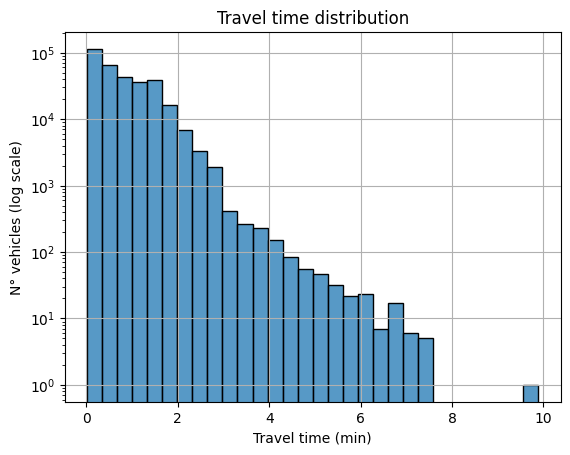

In [5]:
df_res["duration"] = (df_res['arrival'] - df_res['depart']) / 60
sns.histplot(df_res["duration"], bins=30)
plt.title('Travel time distribution')
plt.xlabel('Travel time (min)')
plt.ylabel("N° vehicles (log scale)")
plt.yscale(value="log")
plt.grid(True)

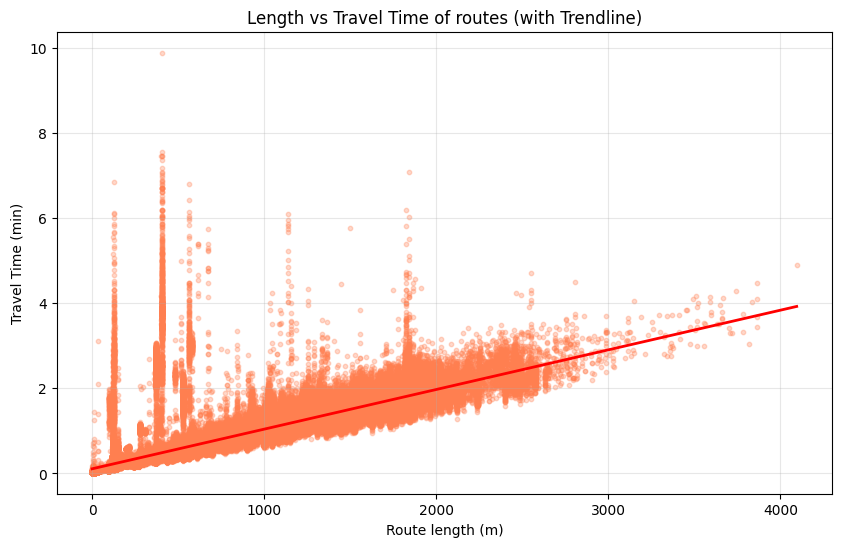

In [6]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_res, 
    x='routeLength', 
    y='duration', 
    color='coral',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Length vs Travel Time of routes (with Trendline)')
plt.xlabel('Route length (m)')
plt.ylabel('Travel Time (min)')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1931012/3386253543.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_edges.values, y=top_edges.index, palette='viridis')


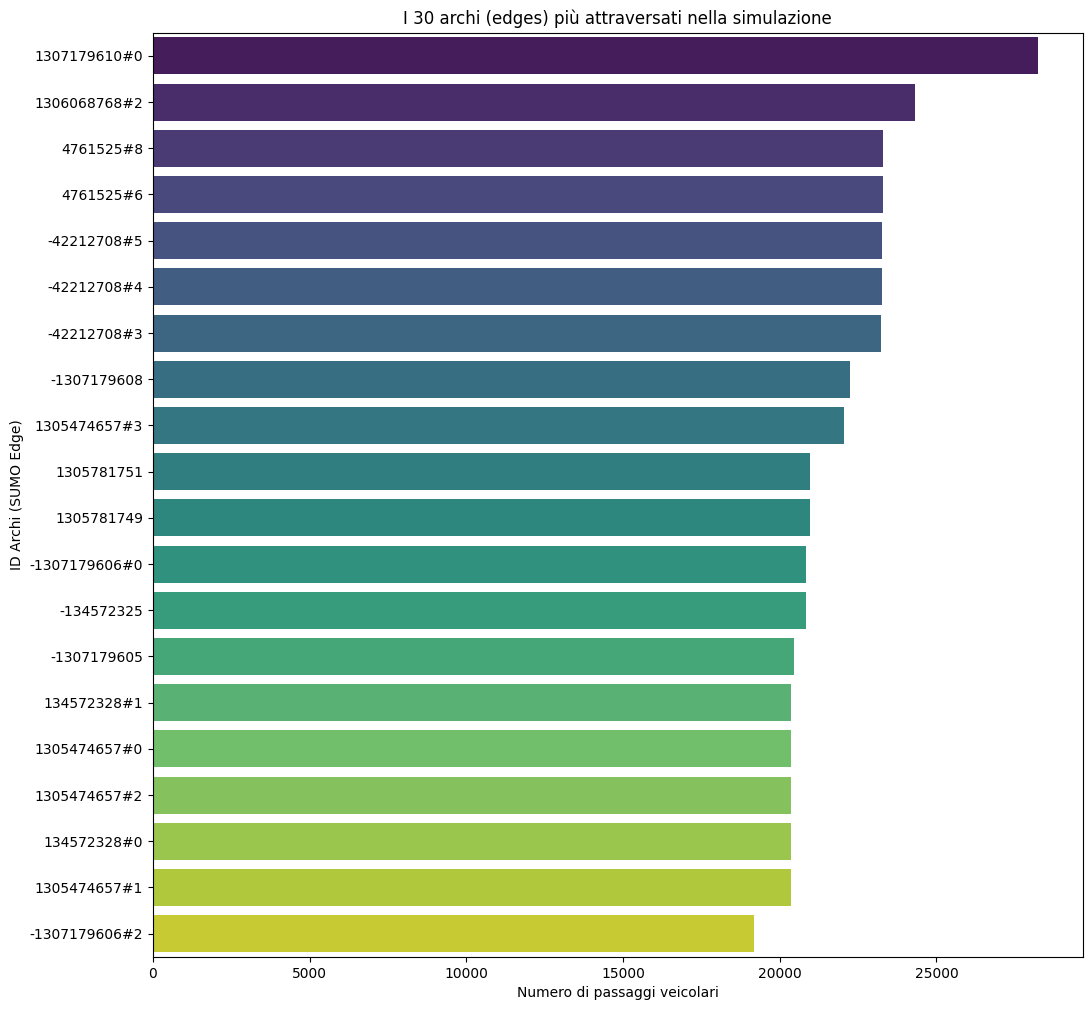

In [7]:
all_edges = df_res['route_edges'].str.split(' ').explode()
top_edges = all_edges.value_counts().head(20)

plt.figure(figsize=(12, 12))
sns.barplot(x=top_edges.values, y=top_edges.index, palette='viridis')
plt.title('I 30 archi (edges) più attraversati nella simulazione')
plt.xlabel('Numero di passaggi veicolari')
plt.ylabel('ID Archi (SUMO Edge)')
plt.show()

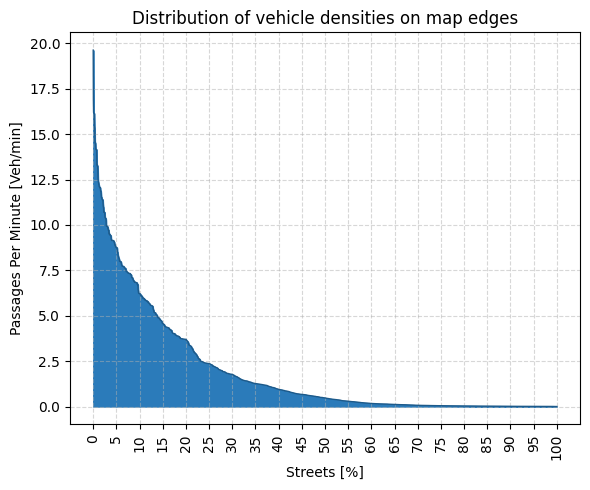

In [8]:
import numpy as np
import matplotlib.pyplot as plt


durata_minuti = (df_res['arrival'].max() - df_res['depart'].min()) / 60.0
edge_counts = df_res['route_edges'].str.split(' ').explode().value_counts()
passages_per_min = (edge_counts / durata_minuti).sort_values(ascending=False).values

num_streets = len(passages_per_min)
streets_percentage = np.linspace(0, 100, num_streets)

plt.figure(figsize=(6, 5))
plt.fill_between(streets_percentage, passages_per_min, color='#2b7bba')
plt.plot(streets_percentage, passages_per_min, color='#1d5a8a', linewidth=1)

plt.title("Distribution of vehicle densities on map edges")
plt.xlabel("Streets [%]")
plt.ylabel("Passages Per Minute [Veh/min]")
plt.xlim(-5, 105)
plt.xticks(ticks=np.arange(0, 101, 5), rotation=90)
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()